## 02_pancreas_eda.ipynb
 Objetivo:
 1) cargar el manifest y split de PANORAMA pancreas
 2) revisar distribución de clases, splits y pacientes
 3) inspeccionar metadatos 3D de los estudios CT
 4) visualizar ejemplos PDAC y non-PDAC
 5) revisar disponibilidad de manual/automatic labels
 6) guardar un resumen reutilizable del EDA

## imports

In [1]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import SimpleITK as sitk

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None

/home/luis_arcia/miniconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## configuración

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path("/mnt/d/Universidad/analitica/proyecto_analitica2")
DATA_DIR = PROJECT_ROOT / "data"
MANIFESTS_DIR = DATA_DIR / "manifests"
WORKING_DIR = DATA_DIR / "working"

PANCREAS_WORKING_DIR = WORKING_DIR / "pancreas"
PANCREAS_WORKING_DIR.mkdir(parents=True, exist_ok=True)

MANIFEST_PATH = MANIFESTS_DIR / "manifest_pancreas.csv"
SPLIT_PATH = MANIFESTS_DIR / "split_final_pancreas.csv"

EDA_CACHE_PATH = PANCREAS_WORKING_DIR / "pancreas_scan_metadata.csv"

print("MANIFEST_PATH:", MANIFEST_PATH)
print("SPLIT_PATH:", SPLIT_PATH)
print("EDA_CACHE_PATH:", EDA_CACHE_PATH)

MANIFEST_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/manifest_pancreas.csv
SPLIT_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/manifests/split_final_pancreas.csv
EDA_CACHE_PATH: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/pancreas/pancreas_scan_metadata.csv


## cargar manifest y split

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)
split_df = pd.read_csv(SPLIT_PATH)

manifest = manifest.merge(
    split_df[["case_id", "split"]],
    on="case_id",
    how="left"
)

print("Shape manifest:", manifest.shape)
display(manifest.head())

Shape manifest: (557, 15)


,image_name,image_path,case_id,patient_id,study_suffix,label_str,label_binary,level,patient_age,patient_sex,scanner,anonymized_study_date,manual_label_path,automatic_label_path,split
0,100000_00001_0000.nii.gz,/mnt/d/Universidad/analitica/proyecto_analitic...,100000_00001,100000,1,non-PDAC,0,radiology,042Y,F,TOSHIBA,2018-10-04,NaN,/mnt/d/Universidad/analitica/proyecto_analitic...,train
1,100001_00001_0000.nii.gz,/mnt/d/Universidad/analitica/proyecto_analitic...,100001_00001,100001,1,non-PDAC,0,radiology,068Y,M,SIEMENS,2014-04-24,NaN,/mnt/d/Universidad/analitica/proyecto_analitic...,val
2,100002_00001_0000.nii.gz,/mnt/d/Universidad/analitica/proyecto_analitic...,100002_00001,100002,1,PDAC,1,pathology,077Y,F,TOSHIBA,2021-03-02,/mnt/d/Universidad/analitica/proyecto_analitic...,NaN,val
3,100003_00001_0000.nii.gz,/mnt/d/Universidad/analitica/proyecto_analitic...,100003_00001,100003,1,PDAC,1,cytology,057Y,M,TOSHIBA,2016-12-28,NaN,/mnt/d/Universidad/analitica/proyecto_analitic...,train
4,100004_00001_0000.nii.gz,/mnt/d/Universidad/analitica/proyecto_analitic...,100004_00001,100004,1,non-PDAC,0,radiology,068Y,M,SIEMENS,2018-02-09,NaN,/mnt/d/Universidad/analitica/proyecto_analitic...,train


## chequeos básicos

In [4]:
print("Número total de estudios:", len(manifest))
print("Pacientes únicos:", manifest["patient_id"].nunique())

print("\nDistribución de clases:")
print(manifest["label_binary"].value_counts().sort_index())

print("\nDistribución por split:")
print(manifest["split"].value_counts())

print("\nDistribución por label_str:")
print(manifest["label_str"].value_counts())

print("\nDisponibilidad de labels volumétricas:")
print("manual_label_path:", int(manifest["manual_label_path"].notna().sum()))
print("automatic_label_path:", int(manifest["automatic_label_path"].notna().sum()))

Número total de estudios: 557
Pacientes únicos: 547

Distribución de clases:
label_binary
0    399
1    158
Name: count, dtype: int64

Distribución por split:
split
train    392
test      83
val       82
Name: count, dtype: int64

Distribución por label_str:
label_str
non-PDAC    399
PDAC        158
Name: count, dtype: int64

Disponibilidad de labels volumétricas:
manual_label_path: 108
automatic_label_path: 449


## tabla clase vs split

In [5]:
ct_split = pd.crosstab(manifest["split"], manifest["label_binary"])
display(ct_split)

label_binary,0,1
split,,
test,59,24
train,281,111
val,59,23


## tabla level vs clase

In [6]:
ct_level = pd.crosstab(manifest["level"], manifest["label_binary"])
display(ct_level)

label_binary,0,1
level,,
MSD_dataset,24,25
NIH_dataset,21,0
cytology,10,43
histopathology,33,48
pathology,19,32
radiology,290,10
radiology / 3yFU,2,0


## helpers para leer imagen y visualizar

In [7]:
def read_volume(path):
    image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(image)  # [z, y, x]
    return image, array


def window_ct_for_display(volume, hu_min=-1000, hu_max=400):
    vol = np.clip(volume, hu_min, hu_max).astype(np.float32)
    vol = (vol - hu_min) / (hu_max - hu_min)
    vol = np.clip(vol, 0.0, 1.0)
    return vol


def show_orthogonal_views(volume, title="", hu_min=-1000, hu_max=400):
    vol = window_ct_for_display(volume, hu_min=hu_min, hu_max=hu_max)

    z, y, x = vol.shape
    zc, yc, xc = z // 2, y // 2, x // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(vol[zc], cmap="gray")
    axes[0].set_title(f"Axial (z={zc})")
    axes[0].axis("off")

    axes[1].imshow(vol[:, yc, :], cmap="gray")
    axes[1].set_title(f"Coronal (y={yc})")
    axes[1].axis("off")

    axes[2].imshow(vol[:, :, xc], cmap="gray")
    axes[2].set_title(f"Sagittal (x={xc})")
    axes[2].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## visualizar un ejemplo PDAC y uno non-PDAC

Ejemplo PDAC:


case_id                                            100430_00001
patient_id                                               100430
split                                                     train
label_str                                                  PDAC
level                                            histopathology
image_path    /mnt/d/Universidad/analitica/proyecto_analitic...
Name: 438, dtype: object

shape PDAC [z,y,x]: (123, 512, 512)
spacing PDAC [x,y,z]: (0.751953125, 0.751953125, 3.0)
intensidad min/max: -1024.0 1710.0


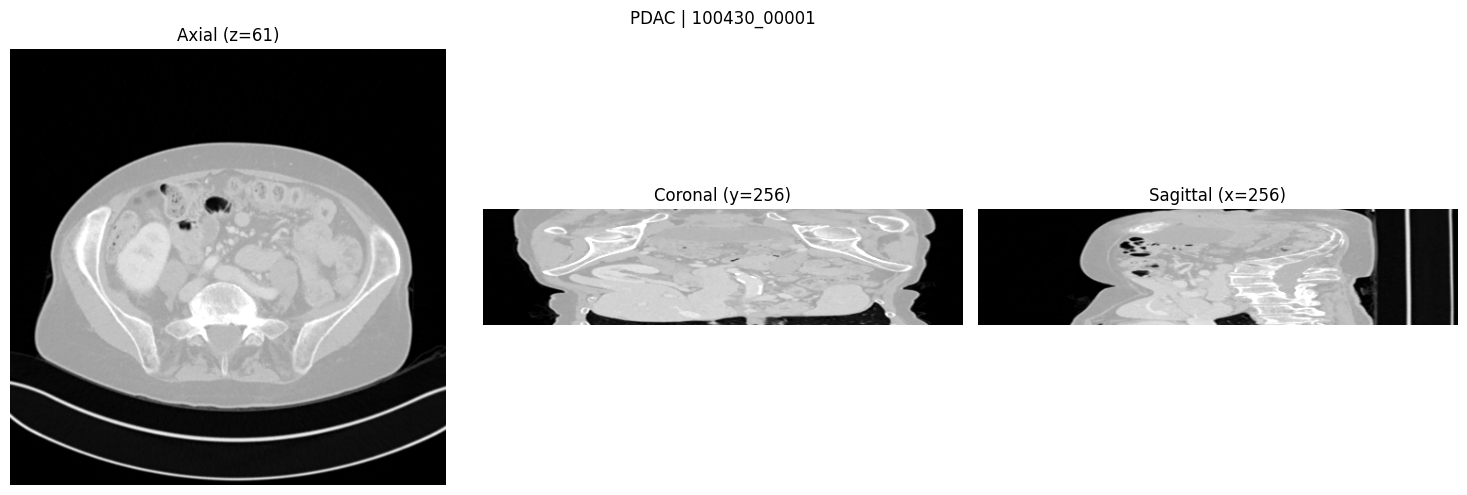

Ejemplo non-PDAC:


case_id                                            100279_00001
patient_id                                               100279
split                                                     train
label_str                                              non-PDAC
level                                            histopathology
image_path    /mnt/d/Universidad/analitica/proyecto_analitic...
Name: 285, dtype: object

shape non-PDAC [z,y,x]: (176, 512, 512)
spacing non-PDAC [x,y,z]: (0.753000020980835, 0.753000020980835, 2.4000000953674316)
intensidad min/max: -2048.0 1541.0


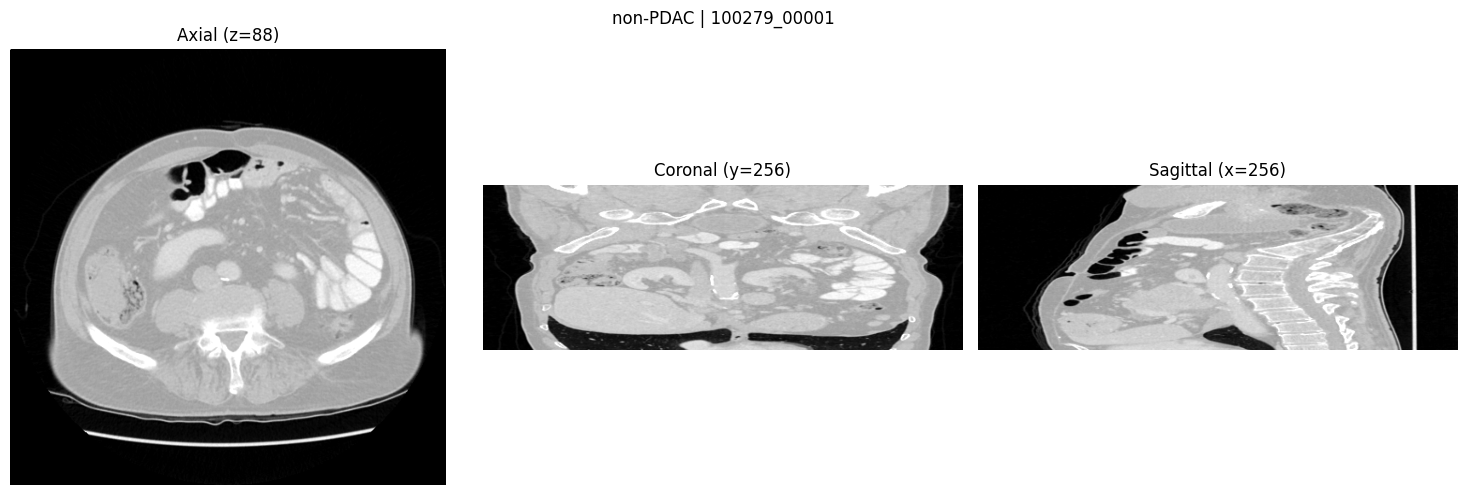

In [8]:
pos_row = manifest[manifest["label_binary"] == 1].sample(1, random_state=SEED).iloc[0]
neg_row = manifest[manifest["label_binary"] == 0].sample(1, random_state=SEED).iloc[0]

print("Ejemplo PDAC:")
display(pos_row[["case_id", "patient_id", "split", "label_str", "level", "image_path"]])

img_pos, vol_pos = read_volume(pos_row["image_path"])
print("shape PDAC [z,y,x]:", vol_pos.shape)
print("spacing PDAC [x,y,z]:", img_pos.GetSpacing())
print("intensidad min/max:", float(vol_pos.min()), float(vol_pos.max()))
show_orthogonal_views(vol_pos, title=f"PDAC | {pos_row['case_id']}")

print("Ejemplo non-PDAC:")
display(neg_row[["case_id", "patient_id", "split", "label_str", "level", "image_path"]])

img_neg, vol_neg = read_volume(neg_row["image_path"])
print("shape non-PDAC [z,y,x]:", vol_neg.shape)
print("spacing non-PDAC [x,y,z]:", img_neg.GetSpacing())
print("intensidad min/max:", float(vol_neg.min()), float(vol_neg.max()))
show_orthogonal_views(vol_neg, title=f"non-PDAC | {neg_row['case_id']}")

## inspeccionar una máscara manual y una automática si existen

In [9]:
manual_rows = manifest[manifest["manual_label_path"].notna()]
auto_rows = manifest[manifest["automatic_label_path"].notna()]

if len(manual_rows) > 0:
    row_m = manual_rows.iloc[0]
    m_img, m_arr = read_volume(row_m["manual_label_path"])
    print("Ejemplo manual label:", row_m["case_id"])
    print("Shape:", m_arr.shape)
    print("Unique values:", np.unique(m_arr)[:20])
    print("Voxels != 0:", int((m_arr != 0).sum()))
else:
    print("No hay manual labels disponibles")

if len(auto_rows) > 0:
    row_a = auto_rows.iloc[0]
    a_img, a_arr = read_volume(row_a["automatic_label_path"])
    print("\nEjemplo automatic label:", row_a["case_id"])
    print("Shape:", a_arr.shape)
    print("Unique values:", np.unique(a_arr)[:20])
    print("Voxels != 0:", int((a_arr != 0).sum()))
else:
    print("No hay automatic labels disponibles")

Ejemplo manual label: 100002_00001
Shape: (561, 512, 512)
Unique values: [0. 1. 2. 3. 4. 5. 6.]
Voxels != 0: 437283

Ejemplo automatic label: 100000_00001
Shape: (90, 512, 512)
Unique values: [0. 2. 3. 4. 6.]
Voxels != 0: 126374


## función para extraer metadatos de un estudio

In [10]:
def extract_scan_metadata(row):
    out = {
        "case_id": row["case_id"],
        "patient_id": row["patient_id"],
        "split": row["split"],
        "label_binary": int(row["label_binary"]),
        "label_str": row["label_str"],
        "level": row["level"],
        "image_path": row["image_path"],
        "has_manual_label": int(pd.notna(row["manual_label_path"])),
        "has_automatic_label": int(pd.notna(row["automatic_label_path"])),
    }

    try:
        image = sitk.ReadImage(str(row["image_path"]))
        volume = sitk.GetArrayFromImage(image).astype(np.float32)

        size_x, size_y, size_z = image.GetSize()
        spacing_x, spacing_y, spacing_z = image.GetSpacing()
        origin_x, origin_y, origin_z = image.GetOrigin()

        out.update({
            "read_ok": 1,
            "size_x": int(size_x),
            "size_y": int(size_y),
            "size_z": int(size_z),
            "shape_z": int(volume.shape[0]),
            "shape_y": int(volume.shape[1]),
            "shape_x": int(volume.shape[2]),
            "spacing_x": float(spacing_x),
            "spacing_y": float(spacing_y),
            "spacing_z": float(spacing_z),
            "origin_x": float(origin_x),
            "origin_y": float(origin_y),
            "origin_z": float(origin_z),
            "int_min": float(volume.min()),
            "int_max": float(volume.max()),
            "int_mean": float(volume.mean()),
            "int_std": float(volume.std()),
            "p01": float(np.percentile(volume, 1)),
            "p50": float(np.percentile(volume, 50)),
            "p99": float(np.percentile(volume, 99)),
            "ratio_below_m1000": float((volume < -1000).mean()),
            "ratio_above_400": float((volume > 400).mean()),
        })
    except Exception as e:
        out.update({
            "read_ok": 0,
            "error": str(e),
        })

    return out

## calcular o cargar cache de metadatos

In [11]:
RECOMPUTE_METADATA = False

if EDA_CACHE_PATH.exists() and not RECOMPUTE_METADATA:
    metadata_df = pd.read_csv(EDA_CACHE_PATH)
    print("Metadatos cargados desde cache:", metadata_df.shape)
else:
    records = manifest.to_dict(orient="records")

    if tqdm is not None:
        iterator = tqdm(records, total=len(records), desc="Extrayendo metadatos")
    else:
        iterator = records

    metadata_rows = [extract_scan_metadata(row) for row in iterator]
    metadata_df = pd.DataFrame(metadata_rows)
    metadata_df.to_csv(EDA_CACHE_PATH, index=False)
    print("Metadatos calculados y guardados en:", EDA_CACHE_PATH)

display(metadata_df.head())

Extrayendo metadatos: 100%|██████████| 557/557 [29:34<00:00,  3.19s/it]

Metadatos calculados y guardados en: /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/pancreas/pancreas_scan_metadata.csv


,case_id,patient_id,split,label_binary,label_str,level,image_path,has_manual_label,has_automatic_label,read_ok,...,origin_z,int_min,int_max,int_mean,int_std,p01,p50,p99,ratio_below_m1000,ratio_above_400
0,100000_00001,100000,train,0,non-PDAC,radiology,/mnt/d/Universidad/analitica/proyecto_analitic...,0,1,1,...,1759.400024,-2048.0,1558.0,-701.454651,824.271057,-2048.0,-133.0,342.0,0.301152,0.008210
1,100001_00001,100001,val,0,non-PDAC,radiology,/mnt/d/Universidad/analitica/proyecto_analitic...,0,1,1,...,-248.500000,-1024.0,2297.0,-541.878662,484.882294,-1024.0,-878.0,338.0,0.182583,0.007071
2,100002_00001,100002,val,1,PDAC,pathology,/mnt/d/Universidad/analitica/proyecto_analitic...,1,0,1,...,1912.500000,-2710.0,13903.0,-812.581299,787.488037,-2048.0,-938.0,365.0,0.309093,0.008545
3,100003_00001,100003,train,1,PDAC,cytology,/mnt/d/Universidad/analitica/proyecto_analitic...,0,1,1,...,1701.500000,-2048.0,1748.0,-705.267883,832.938049,-2048.0,-814.0,475.0,0.299647,0.013332
4,100004_00001,100004,train,0,non-PDAC,radiology,/mnt/d/Universidad/analitica/proyecto_analitic...,0,1,1,...,851.099976,-1024.0,3071.0,-450.315247,493.651581,-1024.0,-115.0,191.0,0.228539,0.002775


## sanity check de lectura

In [12]:
print("Distribución read_ok:")
print(metadata_df["read_ok"].value_counts(dropna=False))

metadata_ok = metadata_df[metadata_df["read_ok"] == 1].copy()
print("\nShape metadata_ok:", metadata_ok.shape)

Distribución read_ok:
read_ok
1    557
Name: count, dtype: int64

Shape metadata_ok: (557, 31)


## estadísticas descriptivas principales

In [13]:
cols_resume = [
    "shape_z", "shape_y", "shape_x",
    "spacing_x", "spacing_y", "spacing_z",
    "int_min", "int_max", "int_mean", "int_std",
    "p01", "p50", "p99"
]

display(metadata_ok[cols_resume].describe().T)

,count,mean,std,min,25%,50%,75%,max
shape_z,557.0,286.332136,213.549960,37.000000,150.000000,221.000000,323.000000,1197.000000
shape_y,557.0,524.868941,80.217459,512.000000,512.000000,512.000000,512.000000,1024.000000
shape_x,557.0,524.868941,80.217459,512.000000,512.000000,512.000000,512.000000,1024.000000
spacing_x,557.0,0.748289,0.101912,0.314713,0.692000,0.748047,0.797000,0.976562
spacing_y,557.0,0.748289,0.101912,0.314713,0.692000,0.748047,0.797000,0.976562
spacing_z,557.0,1.949835,1.034509,0.449951,1.250000,1.500000,2.500000,8.000000
int_min,557.0,-1499.786206,876.206050,-8035.000000,-2048.000000,-1024.000000,-1024.000000,-1023.916565
int_max,557.0,3369.159785,4002.373157,1212.000000,1696.000000,2299.000000,3071.000000,31575.000000
int_mean,557.0,-594.473732,137.418101,-944.750854,-705.267883,-573.250732,-485.804565,-233.315903
int_std,557.0,602.883805,158.569661,401.697052,487.238586,503.739624,797.130554,1200.739990


## histogramas de shape y spacing

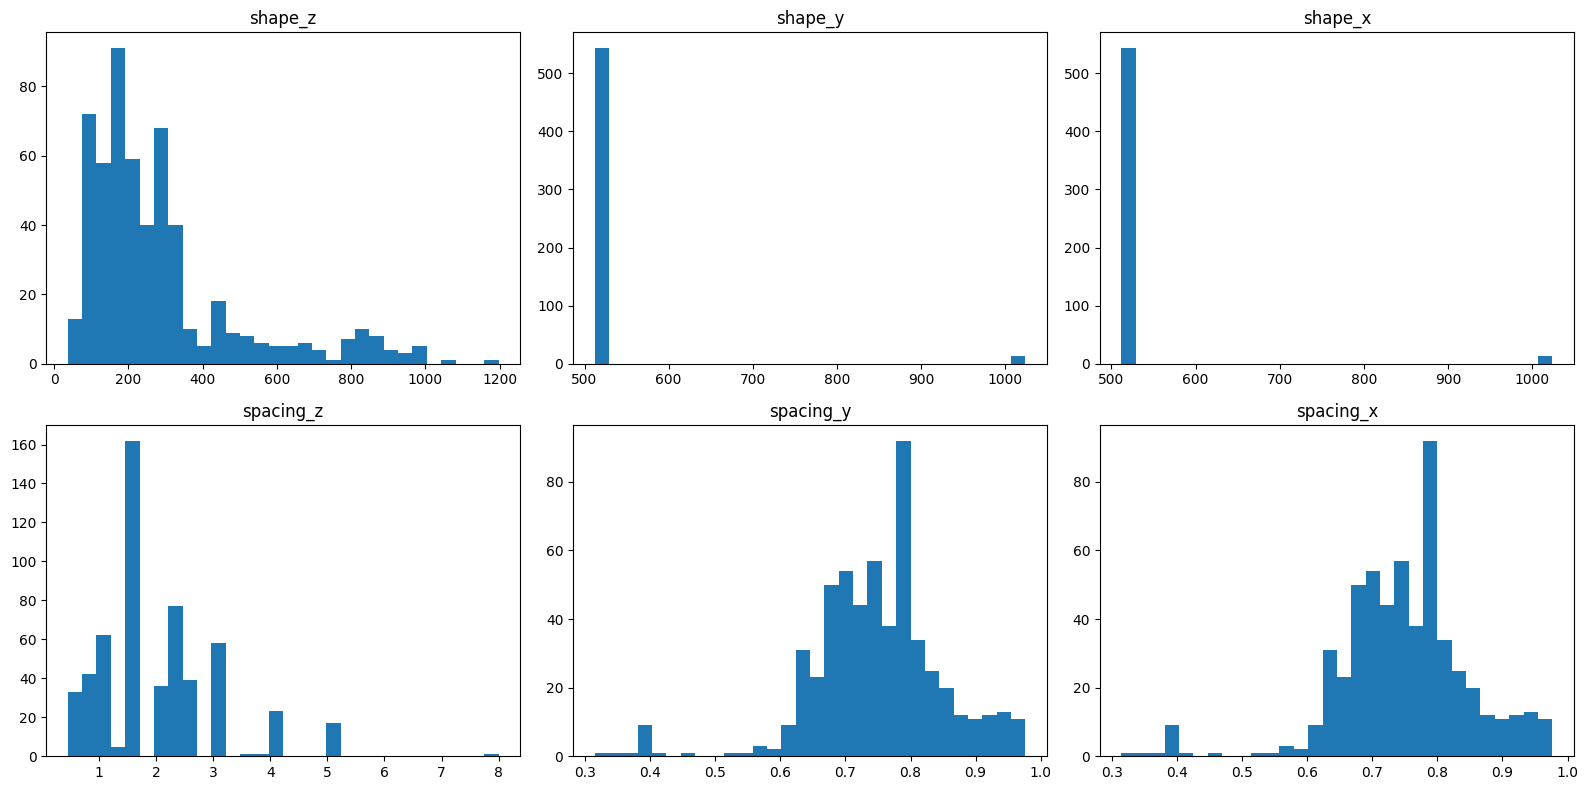

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(metadata_ok["shape_z"], bins=30)
axes[0, 0].set_title("shape_z")

axes[0, 1].hist(metadata_ok["shape_y"], bins=30)
axes[0, 1].set_title("shape_y")

axes[0, 2].hist(metadata_ok["shape_x"], bins=30)
axes[0, 2].set_title("shape_x")

axes[1, 0].hist(metadata_ok["spacing_z"], bins=30)
axes[1, 0].set_title("spacing_z")

axes[1, 1].hist(metadata_ok["spacing_y"], bins=30)
axes[1, 1].set_title("spacing_y")

axes[1, 2].hist(metadata_ok["spacing_x"], bins=30)
axes[1, 2].set_title("spacing_x")

plt.tight_layout()
plt.show()


## histogramas de intensidad

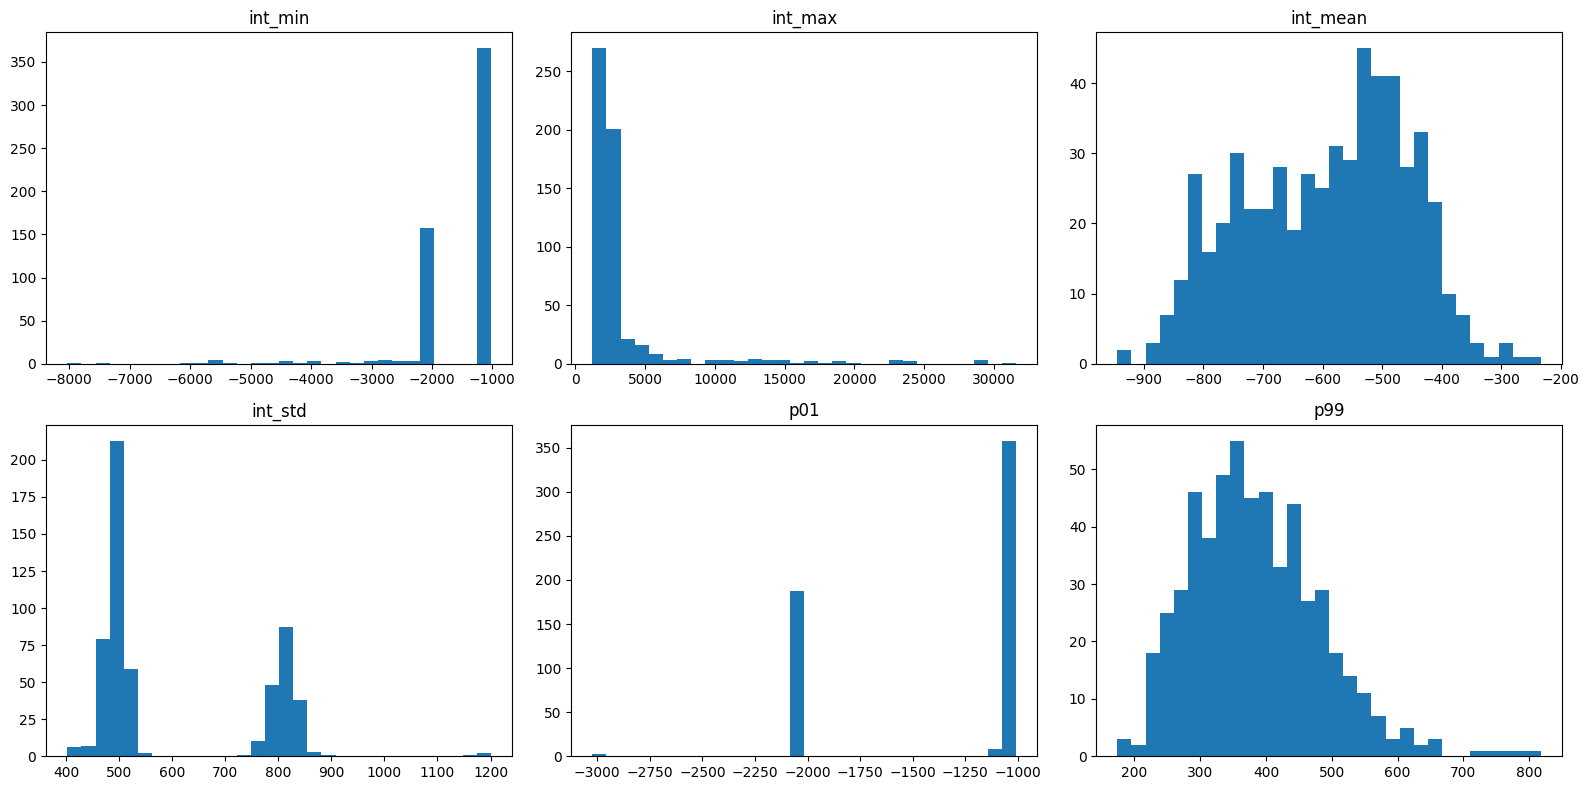

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

axes[0, 0].hist(metadata_ok["int_min"], bins=30)
axes[0, 0].set_title("int_min")

axes[0, 1].hist(metadata_ok["int_max"], bins=30)
axes[0, 1].set_title("int_max")

axes[0, 2].hist(metadata_ok["int_mean"], bins=30)
axes[0, 2].set_title("int_mean")

axes[1, 0].hist(metadata_ok["int_std"], bins=30)
axes[1, 0].set_title("int_std")

axes[1, 1].hist(metadata_ok["p01"], bins=30)
axes[1, 1].set_title("p01")

axes[1, 2].hist(metadata_ok["p99"], bins=30)
axes[1, 2].set_title("p99")

plt.tight_layout()
plt.show()

## comparación por clase

In [16]:
group_stats = (
    metadata_ok.groupby("label_binary")[
        ["shape_z", "spacing_z", "int_mean", "int_std", "p01", "p99"]
    ]
    .agg(["mean", "std", "median"])
)

display(group_stats)

shape_z                    spacing_z                      \
                    mean         std median      mean       std    median   
label_binary                                                                
0             284.679198  210.187706  225.0  1.872165  0.966979  1.500000   
1             290.506329  222.443860  213.0  2.145977  1.168594  2.061604   

                int_mean                             int_std              \
                    mean         std      median        mean         std   
label_binary                                                               
0            -600.666441  131.641019 -584.091858  615.698236  160.465968   
1            -578.835181  150.335704 -545.210052  570.523312  149.330607   

                                  p01                             p99  \
                  median         mean         std  median        mean   
label_binary                                                            
0             507.575714 -1417.027569  503.101118 -1024.0  385.355890   
1             499.028000 -1288.486814  477.237470 -1024.0  384.987414   

                                 
                     std median  
label_binary                     
0              95.496553  373.0  
1             106.761129  368.5

## comparación manual vs automática

In [17]:
label_availability_stats = (
    metadata_ok.groupby(["label_binary", "has_manual_label", "has_automatic_label"])
    .size()
    .reset_index(name="n_cases")
)

display(label_availability_stats.sort_values("n_cases", ascending=False))

,label_binary,has_manual_label,has_automatic_label,n_cases
0,0,0,1,399
2,1,1,0,108
1,1,0,1,50


## boxplots útiles por clase

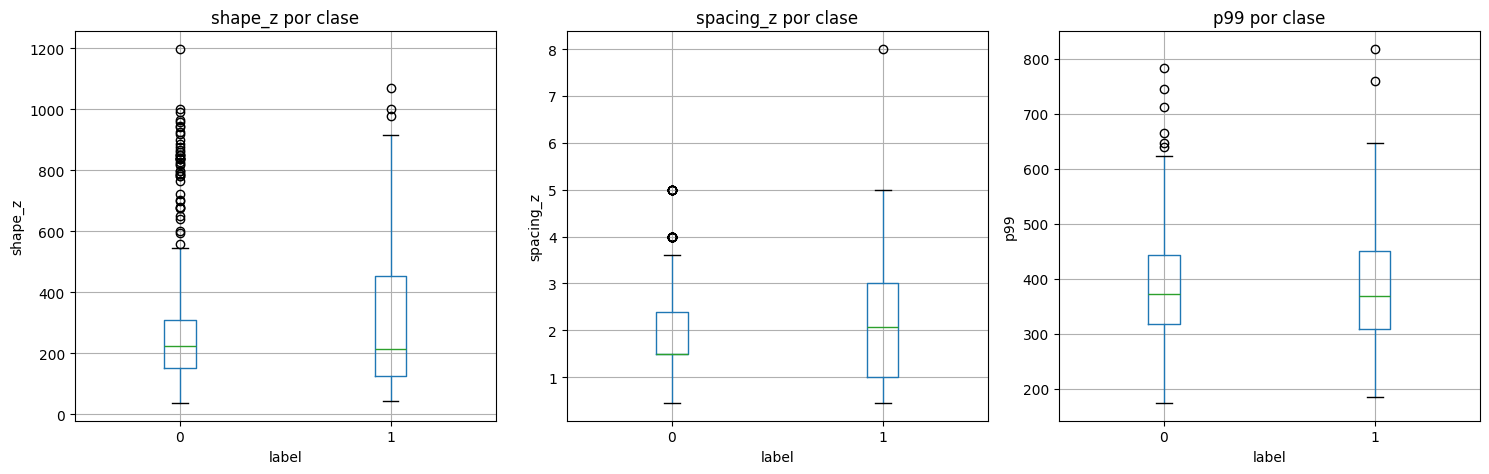

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metadata_ok.boxplot(column="shape_z", by="label_binary", ax=axes[0])
axes[0].set_title("shape_z por clase")
axes[0].set_xlabel("label")
axes[0].set_ylabel("shape_z")

metadata_ok.boxplot(column="spacing_z", by="label_binary", ax=axes[1])
axes[1].set_title("spacing_z por clase")
axes[1].set_xlabel("label")
axes[1].set_ylabel("spacing_z")

metadata_ok.boxplot(column="p99", by="label_binary", ax=axes[2])
axes[2].set_title("p99 por clase")
axes[2].set_xlabel("label")
axes[2].set_ylabel("p99")

plt.suptitle("")
plt.tight_layout()
plt.show()

## guardar resúmenes del EDA

In [19]:
eda_summary_basic_path = PANCREAS_WORKING_DIR / "pancreas_eda_basic_counts.csv"
eda_split_path = PANCREAS_WORKING_DIR / "pancreas_eda_split_vs_class.csv"
eda_level_path = PANCREAS_WORKING_DIR / "pancreas_eda_level_vs_class.csv"

basic_counts_df = pd.DataFrame({
    "metric": [
        "n_studies",
        "n_patients",
        "n_pdac",
        "n_non_pdac",
        "n_train",
        "n_val",
        "n_test",
        "n_manual_labels",
        "n_automatic_labels",
    ],
    "value": [
        len(manifest),
        manifest["patient_id"].nunique(),
        int((manifest["label_binary"] == 1).sum()),
        int((manifest["label_binary"] == 0).sum()),
        int((manifest["split"] == "train").sum()),
        int((manifest["split"] == "val").sum()),
        int((manifest["split"] == "test").sum()),
        int(manifest["manual_label_path"].notna().sum()),
        int(manifest["automatic_label_path"].notna().sum()),
    ]
})

basic_counts_df.to_csv(eda_summary_basic_path, index=False)
ct_split.to_csv(eda_split_path)
ct_level.to_csv(eda_level_path)

print("Guardado:")
print(" -", eda_summary_basic_path)
print(" -", eda_split_path)
print(" -", eda_level_path)
print(" -", EDA_CACHE_PATH)

Guardado:
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/pancreas/pancreas_eda_basic_counts.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/pancreas/pancreas_eda_split_vs_class.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/pancreas/pancreas_eda_level_vs_class.csv
 - /mnt/d/Universidad/analitica/proyecto_analitica2/data/working/pancreas/pancreas_scan_metadata.csv


## conclusión automática rápida

In [20]:
print("Resumen rápido PANCREAS EDA")
print("-" * 40)
print("Estudios analizados:", len(metadata_ok))
print("PDAC:", int((metadata_ok["label_binary"] == 1).sum()))
print("non-PDAC:", int((metadata_ok["label_binary"] == 0).sum()))
print("shape_z mediana:", round(metadata_ok["shape_z"].median(), 2))
print("spacing_z mediana:", round(metadata_ok["spacing_z"].median(), 4))
print("p01 mediana:", round(metadata_ok["p01"].median(), 2))
print("p99 mediana:", round(metadata_ok["p99"].median(), 2))
print("Con manual label:", int(metadata_ok["has_manual_label"].sum()))
print("Con automatic label:", int(metadata_ok["has_automatic_label"].sum()))

Resumen rápido PANCREAS EDA
----------------------------------------
Estudios analizados: 557
PDAC: 158
non-PDAC: 399
shape_z mediana: 221.0
spacing_z mediana: 1.5
p01 mediana: -1024.0
p99 mediana: 372.0
Con manual label: 108
Con automatic label: 449
